# 1. Import Libraries

In [1]:
import os
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import train_test_split

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


2026-05-07 07:11:59.103320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778137919.319337      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778137919.379672      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778137919.869402      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778137919.869456      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778137919.869459      57 computation_placer.cc:177] computation placer alr

In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sauryabhattacharya
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation/test
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation/test/pituitary_tumor
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation/test/meningioma_tumor
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation/test/glioma_tumor
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation/test/normal
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation/train
/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation/train/pituitary_tumor
/kag

# 2. DataSets Path

In [4]:
dataset_path = Path("/kaggle/input/datasets/sauryabhattacharya/braintumorclassification/Brain Tumor Classifcation")

train_src = dataset_path / "train"
test_src = dataset_path / "test"

print("Dataset exists:", dataset_path.exists())
print("Training folder exists:", train_src.exists())
print("Testing folder exists:", test_src.exists())

print("Train classes:", [p.name for p in train_src.iterdir() if p.is_dir()])
print("Test classes:", [p.name for p in test_src.iterdir() if p.is_dir()])

Dataset exists: True
Training folder exists: True
Testing folder exists: True
Train classes: ['pituitary_tumor', 'meningioma_tumor', 'glioma_tumor', 'normal']
Test classes: ['pituitary_tumor', 'meningioma_tumor', 'glioma_tumor', 'normal']


# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.

# Data Understanding, Analysis, Visualization and Cleaning:


###  What does the dataset represent? Provide a brief description.

The dataset represents MRI brain images used for brain tumor classification. It contains images from four classes: glioma tumor, meningioma tumor, pituitary tumor, and normal brain MRI images. The purpose of this dataset is to train deep learning models to classify whether an MRI image belongs to one of the tumor categories or the normal class. 

###  How many total images are in the dataset?


In [5]:
def create_image_dataframe(directory):
    data = []
    total_images = 0
    corrupted_images = 0
    corrupted_paths = []

    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue

        for img_path in class_dir.glob("*"):
            if not img_path.is_file():
                continue

            total_images += 1

            try:
                with Image.open(img_path) as img:
                    img.verify()

                data.append({
                    "file_path": str(img_path),
                    "class": class_dir.name
                })

            except Exception:
                corrupted_images += 1
                corrupted_paths.append(str(img_path))

    dataframe = pd.DataFrame(data)
    return dataframe, total_images, corrupted_images, corrupted_paths


In [6]:
train_df, train_total, train_corrupted, train_corrupted_paths = create_image_dataframe(train_src)
test_df, test_total, test_corrupted, test_corrupted_paths = create_image_dataframe(test_src)

print("Training images:", train_total)
print("Corrupted training images:", train_corrupted)

print("Testing images:", test_total)
print("Corrupted testing images:", test_corrupted)

print("Total images:", train_total + test_total)
print("Total corrupted images:", train_corrupted + test_corrupted)
print("Total readable images:", len(train_df) + len(test_df))


Training images: 2475
Corrupted training images: 28
Testing images: 621
Corrupted testing images: 0
Total images: 3096
Total corrupted images: 28
Total readable images: 3068


The dataset initially contained 3,096 images in total. Out of these, 2,475 images were in the training set and 621 images were in the testing set. During image verification, 28 corrupted images were found in the training set and no corrupted images were found in the testing set. After removing the corrupted images, the final readable dataset contained 3,068 images.


The readable image file paths and their corresponding class labels were stored in two dataframes: train_df for the training images and test_df for the testing images. Corrupted images were not added to these dataframes, so only valid and readable images were used for model training, validation, and evaluation.

In [7]:
def inspect_readable_images(directory):
    data = []

    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue

        for img_path in class_dir.glob("*"):
            if not img_path.is_file():
                continue

            try:
                with Image.open(img_path) as img:
                    data.append({
                        "class": class_dir.name,
                        "file_name": img_path.name,
                        "image_format": img.format,
                        "width": img.size[0],
                        "height": img.size[1],
                        "mode": img.mode
                    })

            except Exception:
                pass

    return pd.DataFrame(data)


train_image_info = inspect_readable_images(train_src)
test_image_info = inspect_readable_images(test_src)

image_info = pd.concat(
    [train_image_info, test_image_info],
    ignore_index=True
)

display(image_info.head())


,class,file_name,image_format,width,height,mode
0,glioma_tumor,G_622.jpg,JPEG,256,256,RGB
1,glioma_tumor,G_774.jpg,JPEG,256,256,RGB
2,glioma_tumor,G_680.jpg,JPEG,256,256,RGB
3,glioma_tumor,G_203.jpg,JPEG,256,256,RGB
4,glioma_tumor,G_894.jpg,JPEG,256,256,RGB


### What is the distribution of images across different classes?

In [8]:
def count_readable_images_by_class(directory):
    data = []

    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue

        readable_count = 0

        for img_path in class_dir.glob("*"):
            if not img_path.is_file():
                continue

            try:
                with Image.open(img_path) as img:
                    img.verify()

                readable_count += 1

            except Exception:
                pass

        data.append({
            "class": class_dir.name,
            "count": readable_count
        })

    return pd.DataFrame(data)


train_distribution = count_readable_images_by_class(train_src)
test_distribution = count_readable_images_by_class(test_src)

total_distribution = train_distribution.merge(
    test_distribution,
    on="class",
    suffixes=("_train", "_test")
)

total_distribution["total"] = (
    total_distribution["count_train"] + total_distribution["count_test"]
)

display(train_distribution)
display(test_distribution)
display(total_distribution)


,class,count
0,glioma_tumor,713
1,meningioma_tumor,723
2,normal,343
3,pituitary_tumor,668


,class,count
0,glioma_tumor,181
1,meningioma_tumor,183
2,normal,88
3,pituitary_tumor,169


,class,count_train,count_test,total
0,glioma_tumor,713,181,894
1,meningioma_tumor,723,183,906
2,normal,343,88,431
3,pituitary_tumor,668,169,837


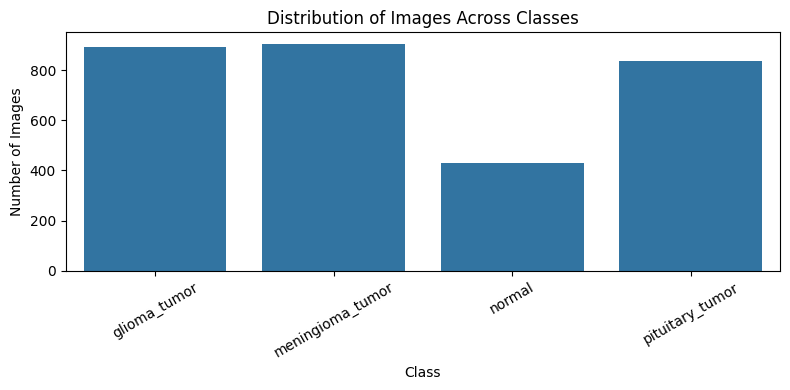

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(data=total_distribution, x="class", y="total")
plt.title("Distribution of Images Across Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


The dataset contains four classes: glioma tumor, meningioma tumor, pituitary tumor, and normal. The class distribution shows that the dataset is imbalanced because the number of images is not equal across all classes. The tumor classes contain more images, while the normal class contains fewer images compared with the other classes.

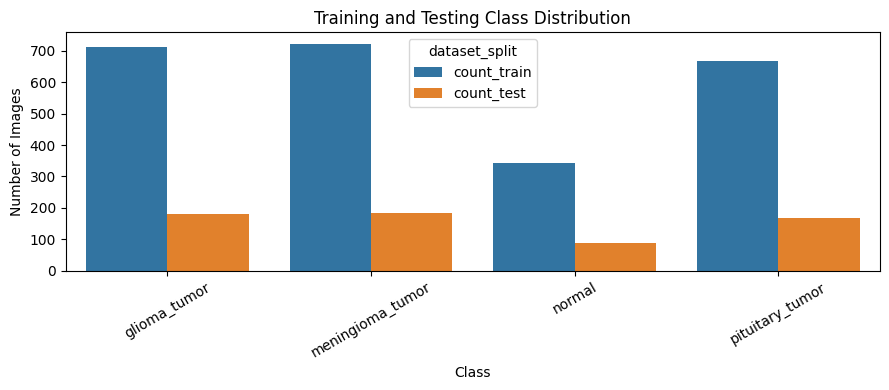

In [10]:
plot_data = total_distribution.melt(
    id_vars="class",
    value_vars=["count_train", "count_test"],
    var_name="dataset_split",
    value_name="count"
)

plt.figure(figsize=(9, 4))
sns.barplot(data=plot_data, x="class", y="count", hue="dataset_split")
plt.title("Training and Testing Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### How is the dataset split into training and validation sets? Justify your choice

In [11]:
class_names = sorted(train_df["class"].unique())
class_to_label = {class_name: index for index, class_name in enumerate(class_names)}

train_df["label"] = train_df["class"].map(class_to_label)
test_df["label"] = test_df["class"].map(class_to_label)

num_classes = len(class_names)

print("Classes:", class_names)
print("Class labels:", class_to_label)
print("Number of classes:", num_classes)


Classes: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
Class labels: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}
Number of classes: 4


In [12]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 1957
Validation images: 490
Testing images: 621


The dataset was split using an 80:20 ratio. From the training folder, 80% of images were used for training and 20% were used for validation using validation_split=0.2.

The 80/20 split was chosen because it allows the model to learn from most of the available training images while still keeping a separate validation set to monitor model performance during training. 


,split,images
0,Training,1957
1,Validation,490
2,Testing,621


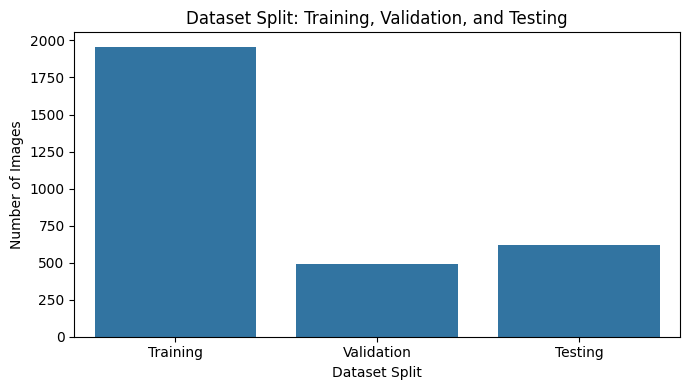

In [13]:
split_data = pd.DataFrame({
    "split": ["Training", "Validation", "Testing"],
    "images": [1957, 490, 621]
})

display(split_data)

plt.figure(figsize=(7, 4))
sns.barplot(data=split_data, x="split", y="images")
plt.title("Dataset Split: Training, Validation, and Testing")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


### What preprocessing techniques (e.g., resizing, normalization) were applied?


In [16]:
img_size = (224, 224)
batch_size = 32
seed = 42
autotune = tf.data.AUTOTUNE

In [17]:
normalization = layers.Rescaling(1.0 / 255)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomBrightness(0.10, value_range=(0.0, 1.0)),
    layers.GaussianNoise(0.01)
], name="data_augmentation")


I0000 00:00:1778138173.819746      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778138173.825445      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [18]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    return image, label


def preprocess_train(path, label):
    image, label = load_image(path, label)
    image = normalization(image)
    image = data_augmentation(image, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def preprocess_valid_test(path, label):
    image, label = load_image(path, label)
    image = normalization(image)
    return image, label


The preprocessing techniques applied were corrupted image removal, resizing, normalization, and data augmentation. Corrupted images were checked and removed before training, so only readable images were used. All images were resized to 224 x 224 pixels to make the input size consistent for the CNN models. Pixel values were normalized by rescaling them from the original 0-255 range to the 0-1 range. Data augmentation such as rotation, zooming, shifting, brightness adjustment, and noise was applied only to the training images to improve model generalization.

### What data generators, if any, were used for preprocessing and augmentation?

A 'tf.data.Dataset' pipeline was used instead of the traditional Keras 'ImageDataGenerator'. The image file paths and labels were converted into TensorFlow datasets, then mapped through preprocessing functions. For the training dataset, the pipeline applied image loading, resizing, normalization, and data augmentation. For the validation and testing datasets, only image loading, resizing, and normalization were applied. Batching and prefetching were also used to make training more efficient.

In [19]:
def make_dataset(dataframe, training=False):
    paths = dataframe["file_path"].values
    labels = dataframe["label"].values.astype("int32")

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=seed,
            reshuffle_each_iteration=True
        )
        dataset = dataset.map(preprocess_train, num_parallel_calls=autotune)
    else:
        dataset = dataset.map(preprocess_valid_test, num_parallel_calls=autotune)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(autotune)

    return dataset


train_ds_prepared = make_dataset(train_df, training=True)
val_ds_prepared = make_dataset(val_df, training=False)
test_ds_prepared = make_dataset(test_df, training=False)

print("Training batches:", len(train_ds_prepared))
print("Validation batches:", len(val_ds_prepared))
print("Testing batches:", len(test_ds_prepared))


Training batches: 62
Validation batches: 16
Testing batches: 20


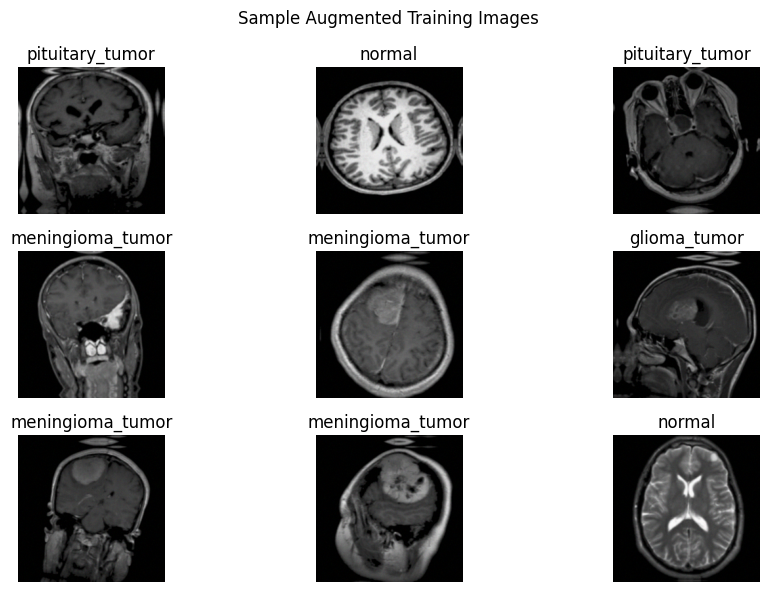

In [20]:
plt.figure(figsize=(10, 6))

for images, labels in train_ds_prepared.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()


The augmented images display changed versions of the original MRI image. Minor rotation, shifting, zooming and brightness adjustments were applied. These transformations add more variety to the dataset and help the model reduce overfitting during training.

# Design, Train, and Evaluate a Baseline Model:


**Helper Functions**

In [21]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="training loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.title(title + " loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="training accuracy")
    plt.plot(history.history["val_accuracy"], label="validation accuracy")
    plt.title(title + " accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [23]:
def evaluate_model(model, dataset, model_name):
    y_true = np.concatenate([y.numpy() for _, y in dataset], axis=0)

    y_prob = model.predict(dataset)
    y_pred = np.argmax(y_prob, axis=1)

    loss, accuracy = model.evaluate(dataset, verbose=0)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(model_name)
    print("loss:", loss)
    print("accuracy:", accuracy)
    print("precision:", precision)
    print("recall:", recall)
    print("f1-score:", f1)

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(model_name + " confusion matrix")
    plt.xlabel("predicted")
    plt.ylabel("actual")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

# Model Architecture:

In [24]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_baseline_model()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,825,028 (98.51 MB)

 Trainable params: 25,825,028 (98.51 MB)

 Non-trainable params: 0 (0.00 B)

The baseline CNN has three convolutional layers, each followed by max pooling. The filters are 32, 64, and 128 with a 3 × 3 kernel size. ReLU activation is used to learn non-linear image features. After feature extraction, the output is flattened and passed through three dense layers with 256, 128, and 64 neurons. The final softmax output layer has four output neurons because the task has four classes. The model has 25,825,028 trainable parameters, with most parameters coming from the dense layers after flattening.

# Model Training:

In [45]:
epochs_baseline = 15

start_time = time.time()

baseline_history = baseline_model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=epochs_baseline,
)

baseline_time = time.time() - start_time
print("Baseline training time:", baseline_time, "seconds")


Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.8429 - loss: 0.4088 - val_accuracy: 0.8469 - val_loss: 0.4339
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.8525 - loss: 0.3739 - val_accuracy: 0.8367 - val_loss: 0.4653
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.8483 - loss: 0.4055 - val_accuracy: 0.8041 - val_loss: 0.5041
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - accuracy: 0.8666 - loss: 0.3740 - val_accuracy: 0.7939 - val_loss: 0.5996
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - accuracy: 0.8493 - loss: 0.3635 - val_accuracy: 0.8265 - val_loss: 0.5056
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy: 0.8588 - loss: 0.3275 - val_accuracy: 0.8306 - val_loss: 0.5109
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 265ms/step - accuracy: 0.8699 - loss: 0.3060 - val_accuracy: 0.8449 - val_loss: 0.5847
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.8752 - loss: 0.3062 - val_accu

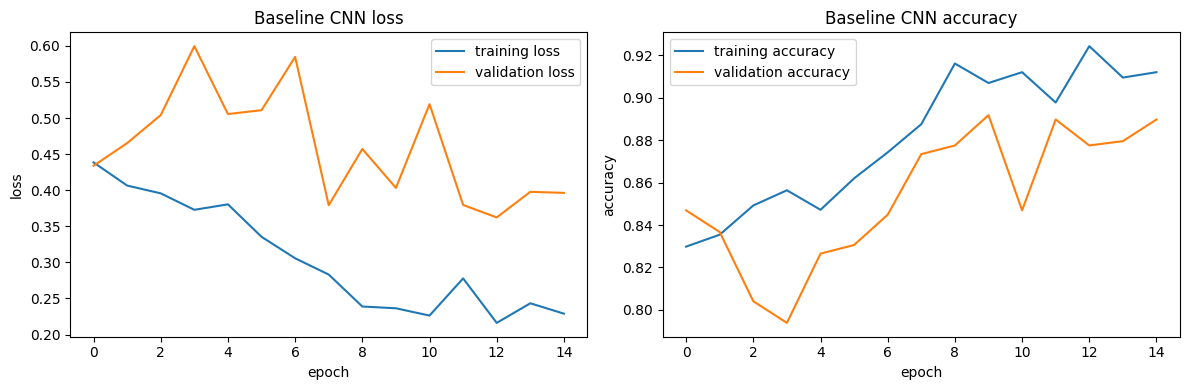

In [46]:
plot_history(baseline_history, "Baseline CNN")

The baseline CNN shows steady learning because training loss decreases and training accuracy increases over epochs. However, the validation curves fluctuate, showing that the model’s performance on unseen data is less stable. Overall, the model is learning, but some overfitting and validation instability are visible.

# Model Evaluation:

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Baseline CNN
loss: 0.40471315383911133
accuracy: 0.8904991745948792
precision: 0.8937605497025788
recall: 0.8904991948470209
f1-score: 0.8910108238139314
                  precision    recall  f1-score   support

    glioma_tumor       0.92      0.84      0.88       181
meningioma_tumor       0.82      0.90      0.86       183
          normal       0.87      0.90      0.88        88
 pituitary_tumor       0.96      0.93      0.95       169

        accuracy                           0.89       621
       macro avg       0.89      0.89      0.89       621
    weighted avg       0.89      0.89      0.89       621



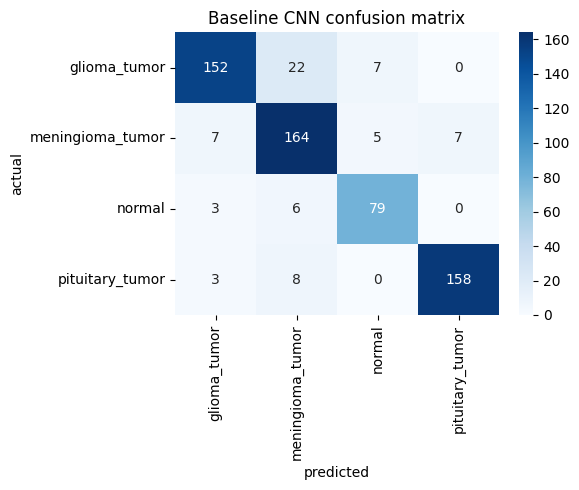

In [47]:
baseline_result = evaluate_model(baseline_model, test_ds_prepared, "Baseline CNN")

# Sample inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


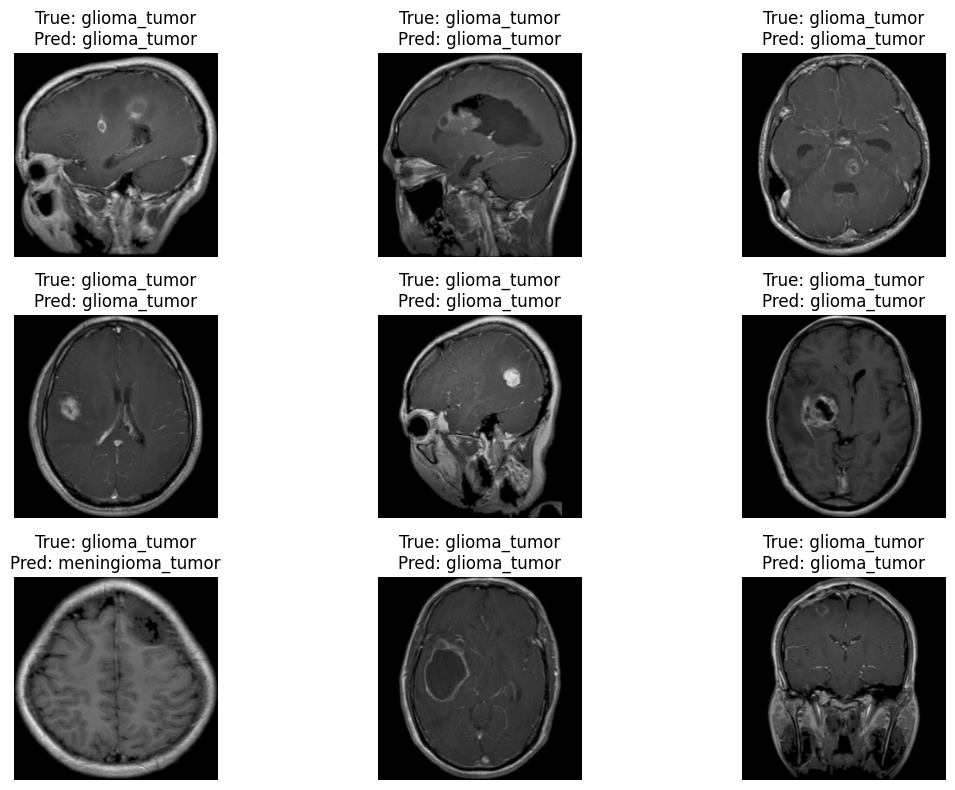

In [48]:
for images, labels in test_ds_prepared.take(1):
    predictions = baseline_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(
            "True: " + class_names[int(labels[i])] +
            "\nPred: " + class_names[int(predicted_labels[i])]
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


The baseline CNN performed well with 89.05% accuracy and an F1-score of 89.10%. The model classified most images correctly and performed best on the pituitary tumor class. Some misclassification occurred between glioma tumor and meningioma tumor, suggesting that these classes may have similar visual features in MRI images. Overall, the model learned useful image patterns, but there is still room for improvement in separating visually similar tumor types.

# Deeper Architecture with Regularization Layer:

# Model Architecture:

In [49]:
def build_deeper_model(input_shape=(224, 224, 3), num_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [50]:
deeper_adam_model = build_deeper_model(
    input_shape=img_size + (3,),
    num_classes=num_classes
)

deeper_adam_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 651,812 (2.49 MB)

 Trainable params: 650,404 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

The model has 651,812 parameters, with 650,404 trainable and 1,408 non-trainable. The final layer has 4 units, so it is made for 4 class classification. Overall, the model is lightweight and efficient for training.

# Model Training:

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 352ms/step - accuracy: 0.8164 - loss: 0.4797 - val_accuracy: 0.7020 - val_loss: 0.7612
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 358ms/step - accuracy: 0.8408 - loss: 0.4140 - val_accuracy: 0.6347 - val_loss: 1.0859
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 355ms/step - accuracy: 0.8568 - loss: 0.3960 - val_accuracy: 0.7163 - val_loss: 0.9113
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - accuracy: 0.8569 - loss: 0.3610 - val_accuracy: 0.7408 - val_loss: 0.6935
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 356ms/step - accuracy: 0.8761 - loss: 0.3496 - val_accuracy: 0.6612 - val_loss: 1.0328
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 359ms/step - accuracy: 0.8689 - loss: 0.3465 - val_accuracy: 0.7449 - val_loss: 0.7480
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 352ms/step - accuracy: 0.8588 - loss: 0.3518 - val_accuracy: 0.7755 - val_loss: 0.6414
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - accuracy: 0.8820 - loss: 0.3432 - val_accu

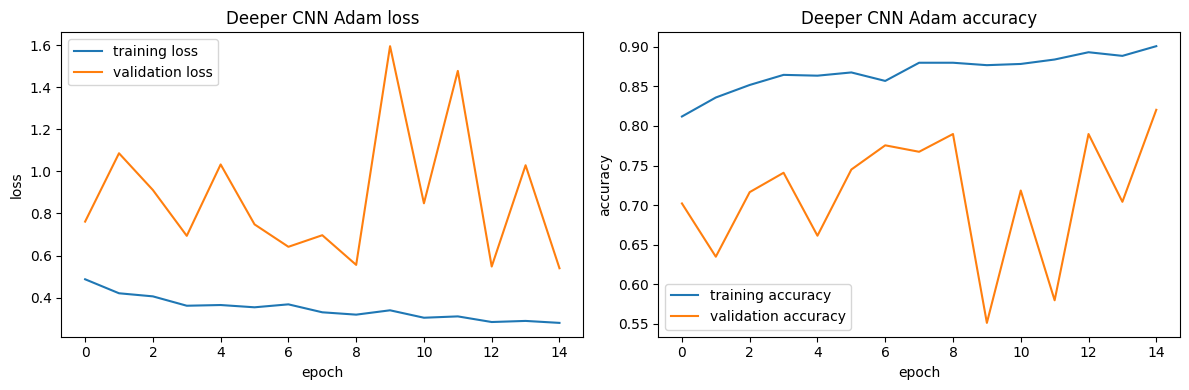

In [54]:
epochs_deeper = 15

start_time = time.time()

deeper_adam_history = deeper_adam_model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=epochs_deeper,
)

deeper_adam_time = time.time() - start_time
print("Deeper CNN Adam training time:", deeper_adam_time, "seconds")

plot_history(deeper_adam_history, "Deeper CNN Adam")

The deeper CNN with Adam shows improving training performance, as training loss decreases and training accuracy increases. However, the validation loss and validation accuracy fluctuate a lot, showing unstable generalization. 

**Compare its training time and loss curves against the baseline model.**

The deeper CNN took 331.48 seconds, while the baseline CNN took 250.40 seconds, so the deeper model required more training time and computation.
The baseline CNN loss curve is more stable because the training loss decreases smoothly and the validation loss fluctuates only moderately. In comparison, the deeper CNN training loss also decreases, but its validation loss changes sharply across epochs. This shows that the deeper CNN learned the training data but generalized less consistently than the baseline model. Therefore, the baseline model had a more stable loss curve.

# Model Evaluation:

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Deeper CNN with Regularization
loss: 0.6153733730316162
accuracy: 0.7954911589622498
precision: 0.8249560132839366
recall: 0.7954911433172303
f1-score: 0.7911995405752189
                  precision    recall  f1-score   support

    glioma_tumor       0.98      0.59      0.73       181
meningioma_tumor       0.69      0.83      0.75       183
          normal       0.75      1.00      0.85        88
 pituitary_tumor       0.84      0.88      0.86       169

        accuracy                           0.80       621
       macro avg       0.82      0.82      0.80       621
    weighted avg       0.82      0.80      0.79       621



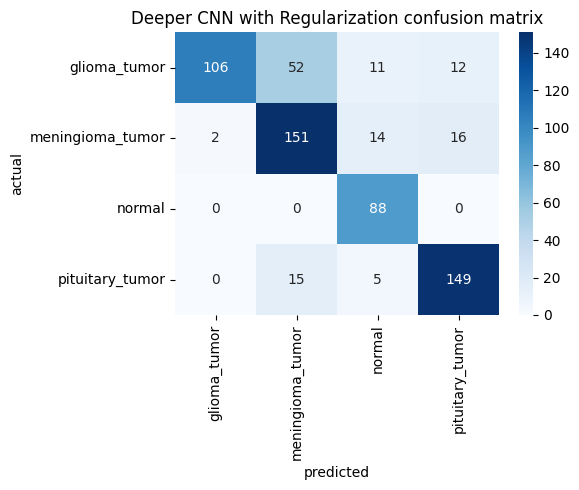

In [55]:
deeper_adam_result = evaluate_model(
    deeper_adam_model,
    test_ds_prepared,
    "Deeper CNN with Regularization"
)

#  Discuss improvements (or lack thereof) compared to the baseline model.

The deeper CNN with regularization did not improve over the baseline model. It achieved about 79.55% accuracy and 79.12% F1-score, which is lower than the baseline CNN. Although the model classified the normal class very well, it made more mistakes between glioma, meningioma, and pituitary tumor classes. This shows that adding more layers, batch normalization, and dropout did not improve performance for this dataset.

# Experimentation and Comparative Analysis:

**Baseline vs. Deeper Model Performance:**

In [56]:
baseline_vs_deeper = pd.DataFrame([
    baseline_result,
    deeper_adam_result
])

display(baseline_vs_deeper)


,model,loss,accuracy,precision,recall,f1_score
0,Baseline CNN,0.404713,0.890499,0.893761,0.890499,0.891011
1,Deeper CNN with Regularization,0.615373,0.795491,0.824956,0.795491,0.791200


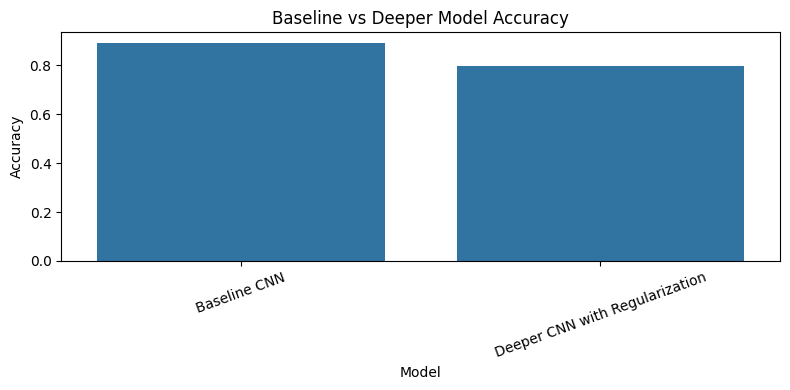

In [57]:
plt.figure(figsize=(8, 4))
sns.barplot(data=baseline_vs_deeper, x="model", y="accuracy")
plt.title("Baseline vs Deeper Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The baseline CNN performed better than the deeper CNN. The baseline achieved 89.05% accuracy, 0.4047 loss, and 89.10% F1-score, while the deeper CNN achieved 79.55% accuracy, 0.6154 loss, and 79.12% F1-score. Precision and recall were also higher for the baseline model. This shows that adding more layers and filters did not improve performance. The deeper model may have overfitted or struggled to generalize because the dataset is relatively small and imbalanced.

**Computational Efficiency:**

In [58]:
efficiency_results = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "training_time_seconds": baseline_time,
        "parameters": baseline_model.count_params()
    },
    {
        "model": "Deeper CNN with Regularization",
        "training_time_seconds": deeper_adam_time,
        "parameters": deeper_adam_model.count_params()
    }
])

display(efficiency_results)


,model,training_time_seconds,parameters
0,Baseline CNN,250.403968,25825028
1,Deeper CNN with Regularization,331.483027,651812


The baseline CNN trained faster, taking 250.40 seconds, while the deeper CNN took 331.48 seconds. The baseline model had more parameters (25,825,028) because of the flatten layer. The deeper CNN had fewer parameters (651,812) due to Global Average Pooling, but it still trained slower because it had more convolutional layers, batch normalization, and dropout. Overall, the baseline model was faster and performed better for this dataset.

**Optimizer Analysis: SGD vs Adam:**

For the optimizer comparison, the deeper CNN trained with Adam was not trained again because it had already been trained earlier in the deeper architecture section. The same trained Adam model, its history, evaluation results, and training time were reused for comparison.

In [82]:
def build_deeper_cnn_sgd(input_shape=(224, 224, 3), num_classes=4):
    model = build_deeper_model(input_shape=input_shape, num_classes=num_classes)

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [83]:
deeper_sgd_model = build_deeper_cnn_sgd(
    input_shape=img_size + (3,),
    num_classes=num_classes
)

deeper_sgd_model.summary()

start_time = time.time()

deeper_sgd_history = deeper_sgd_model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=epochs_deeper
)

deeper_sgd_time = time.time() - start_time

print("Deeper CNN SGD training time:", deeper_sgd_time, "seconds")


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 651,812 (2.49 MB)

 Trainable params: 650,404 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 458ms/step - accuracy: 0.4134 - loss: 1.3675 - val_accuracy: 0.2959 - val_loss: 1.4510
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 363ms/step - accuracy: 0.4810 - loss: 1.1766 - val_accuracy: 0.2918 - val_loss: 2.3033
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 358ms/step - accuracy: 0.5433 - loss: 1.0942 - val_accuracy: 0.3184 - val_loss: 3.0568
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 353ms/step - accuracy: 0.5545 - loss: 1.0169 - val_accuracy: 0.3020 - val_loss: 3.6950
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 354ms/step - accuracy: 0.5521 - loss: 0.9805 - val_accuracy: 0.3265 - val_loss: 1.8201
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 361ms/step - accuracy: 0.6160 - loss: 0.9141 - val_accuracy: 0.3306 - val_loss: 2.1615
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 354ms/step - accuracy: 0.6225 - loss: 0.8889 - val_accuracy: 0.5327 - val_loss: 1.1828
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - accuracy: 0.6398 - loss: 0.8665 - val_accu

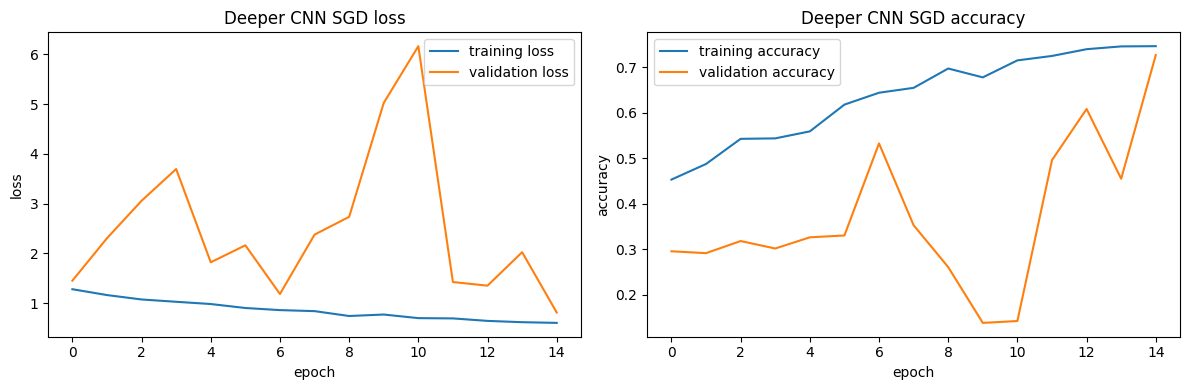

In [84]:
plot_history(deeper_sgd_history, "Deeper CNN SGD")

The SGD model shows unstable validation performance. Training loss decreases and training accuracy increases, meaning the model learns the training data. However, validation loss fluctuates heavily and validation accuracy rises and falls, showing poor generalization. This suggests SGD was less stable than Adam for this dataset.

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step
Deeper CNN SGD
loss: 0.8039237260818481
accuracy: 0.6988728046417236
precision: 0.7233016494214817
recall: 0.6988727858293076
f1-score: 0.693044027467991
                  precision    recall  f1-score   support

    glioma_tumor       0.88      0.64      0.74       181
meningioma_tumor       0.67      0.52      0.59       183
          normal       0.71      0.73      0.72        88
 pituitary_tumor       0.62      0.95      0.75       169

        accuracy                           0.70       621
       macro avg       0.72      0.71      0.70       621
    weighted avg       0.72      0.70      0.69       621



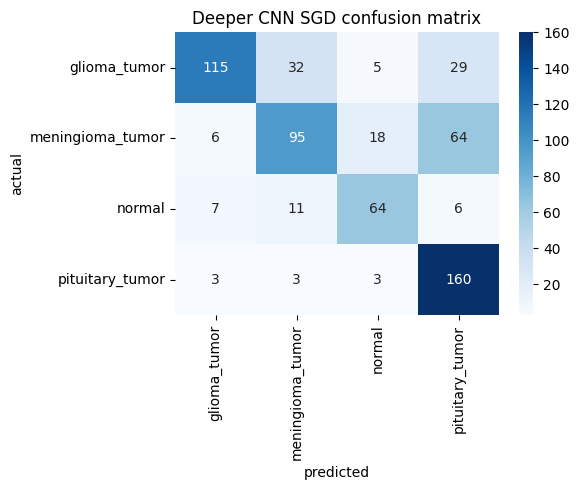

{'model': 'Deeper CNN SGD',
 'loss': 0.8039237260818481,
 'accuracy': 0.6988728046417236,
 'precision': 0.7233016494214817,
 'recall': 0.6988727858293076,
 'f1_score': 0.693044027467991}

In [85]:
deeper_sgd_result = evaluate_model(
    deeper_sgd_model,
    test_ds_prepared,
    "Deeper CNN SGD"
)

deeper_sgd_result


The deeper CNN with SGD achieved about 69.89% accuracy, which is lower than the Adam version and the baseline CNN. It performed well on pituitary tumor but made many mistakes in glioma and meningioma classes. This shows that SGD did not perform as effectively as Adam for this model.

In [86]:
optimizer_results = pd.DataFrame([
    deeper_adam_result,
    deeper_sgd_result
])

display(optimizer_results)


,model,loss,accuracy,precision,recall,f1_score
0,Deeper CNN with Regularization,0.615373,0.795491,0.824956,0.795491,0.791200
1,Deeper CNN SGD,0.803924,0.698873,0.723302,0.698873,0.693044


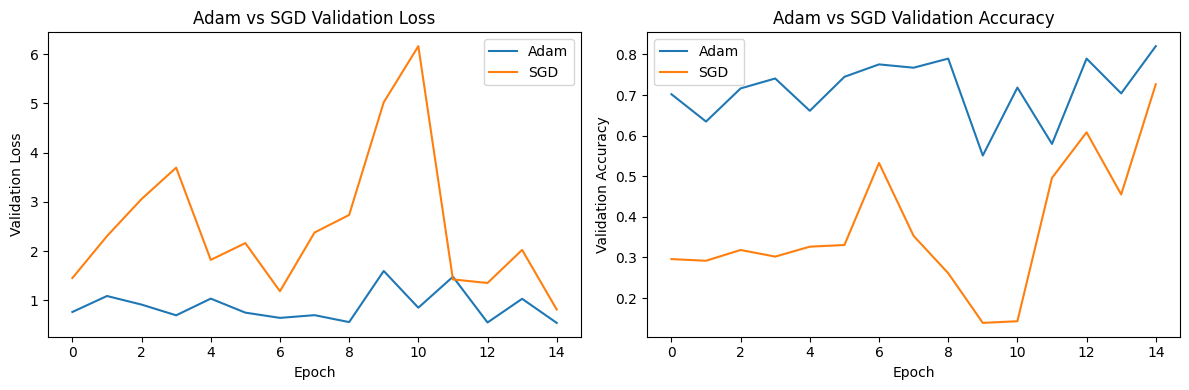

In [87]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(deeper_adam_history.history["val_loss"], label="Adam")
plt.plot(deeper_sgd_history.history["val_loss"], label="SGD")
plt.title("Adam vs SGD Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deeper_adam_history.history["val_accuracy"], label="Adam")
plt.plot(deeper_sgd_history.history["val_accuracy"], label="SGD")
plt.title("Adam vs SGD Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


**Compare the impact of these optimizers on convergence speed and final performance.**

The Adam optimizer performed better than SGD in this experiment. With Adam, the deeper CNN achieved 79.55% accuracy and 79.12% F1-score, while SGD achieved about 69.89% accuracy and 68.79% F1-score. Adam showed more stable validation loss and higher validation accuracy, while SGD fluctuated more during training. Overall, Adam converged better and was more effective for this model.

**Ablation Study:**

In this ablation study, dropout was removed from the deeper CNN to examine its effect on model performance.

In [88]:
def build_deeper_cnn_without_dropout(input_shape=(224, 224, 3), num_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [92]:
ablation_model = build_deeper_cnn_without_dropout(
    input_shape=img_size + (3,),
    num_classes=num_classes
)

ablation_model.summary()

start_time = time.time()

ablation_history = ablation_model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=epochs_deeper
)

ablation_time = time.time() - start_time

print("Ablation training time:", ablation_time, "seconds")


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_80 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_83          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 13,463,716 (51.36 MB)

 Trainable params: 13,462,308 (51.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 447ms/step - accuracy: 0.4218 - loss: 1.9915 - val_accuracy: 0.2918 - val_loss: 2.6785
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 364ms/step - accuracy: 0.6353 - loss: 0.8893 - val_accuracy: 0.2918 - val_loss: 4.7206
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 356ms/step - accuracy: 0.6926 - loss: 0.7750 - val_accuracy: 0.2918 - val_loss: 5.6335
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 352ms/step - accuracy: 0.7210 - loss: 0.6907 - val_accuracy: 0.2959 - val_loss: 5.2781
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 358ms/step - accuracy: 0.7853 - loss: 0.5639 - val_accuracy: 0.3776 - val_loss: 2.5990
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 361ms/step - accuracy: 0.7877 - loss: 0.5309 - val_accuracy: 0.5184 - val_loss: 2.1179
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 358ms/step - accuracy: 0.8265 - loss: 0.4274 - val_accuracy: 0.6347 - val_loss: 0.9474
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 357ms/step - accuracy: 0.8215 - loss: 0.4554 - val_accu

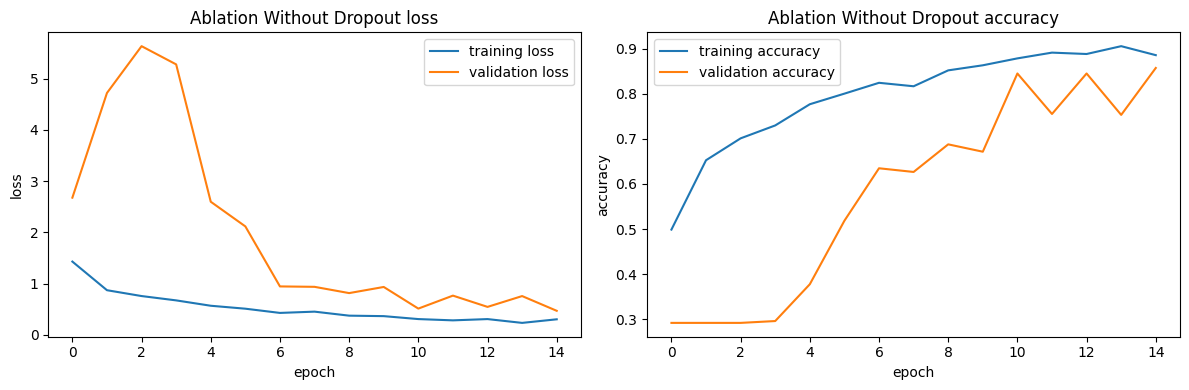

In [93]:
plot_history(ablation_history, "Ablation Without Dropout")

The ablation model without dropout shows better learning over time. Training loss decreases and validation accuracy improves, though validation curves still fluctuate slightly.

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step
Ablation Without Dropout
loss: 0.5602819323539734
accuracy: 0.8373590707778931
precision: 0.8437290429716692
recall: 0.8373590982286635
f1-score: 0.8341577829494616
                  precision    recall  f1-score   support

    glioma_tumor       0.76      0.89      0.82       181
meningioma_tumor       0.86      0.65      0.74       183
          normal       0.80      0.90      0.84        88
 pituitary_tumor       0.94      0.95      0.95       169

        accuracy                           0.84       621
       macro avg       0.84      0.85      0.84       621
    weighted avg       0.84      0.84      0.83       621



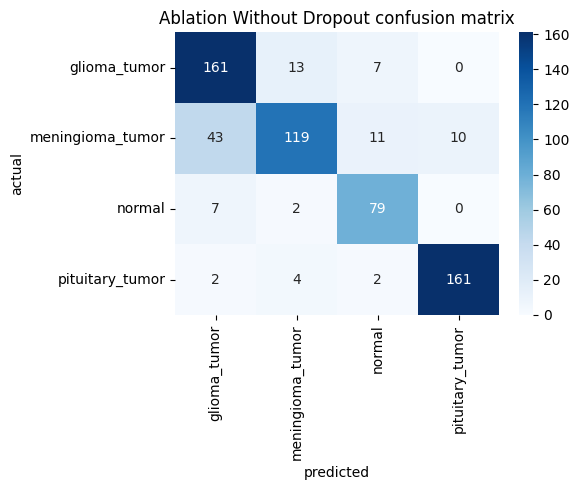

{'model': 'Ablation Without Dropout',
 'loss': 0.5602819323539734,
 'accuracy': 0.8373590707778931,
 'precision': 0.8437290429716692,
 'recall': 0.8373590982286635,
 'f1_score': 0.8341577829494616}

In [94]:
ablation_result = evaluate_model(
    ablation_model,
    test_ds_prepared,
    "Ablation Without Dropout"
)

ablation_result


It achieved about 83.74% accuracy and 83.42% F1-score. The confusion matrix shows strong performance on glioma, normal, and pituitary tumor, but some meningioma images were misclassified as glioma. Overall, removing dropout improved performance in this experiment.

In [95]:
ablation_comparison = pd.DataFrame([
    deeper_adam_result,
    ablation_result
])

display(ablation_comparison)


,model,loss,accuracy,precision,recall,f1_score
0,Deeper CNN with Regularization,0.615373,0.795491,0.824956,0.795491,0.791200
1,Ablation Without Dropout,0.560282,0.837359,0.843729,0.837359,0.834158


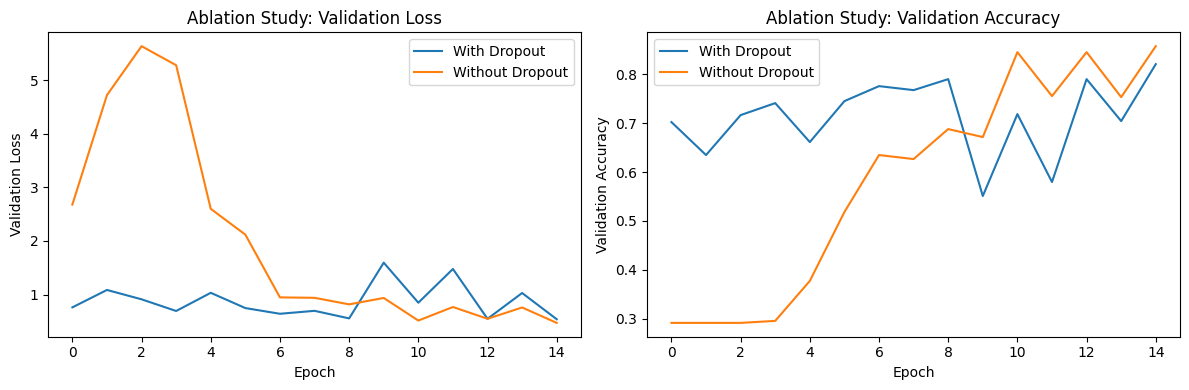

In [96]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(deeper_adam_history.history["val_loss"], label="With Dropout")
plt.plot(ablation_history.history["val_loss"], label="Without Dropout")
plt.title("Ablation Study: Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deeper_adam_history.history["val_accuracy"], label="With Dropout")
plt.plot(ablation_history.history["val_accuracy"], label="Without Dropout")
plt.title("Ablation Study: Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


The ablation comparison shows that the model without dropout improved after the early epochs and reached higher validation accuracy by the end. The model with dropout was more stable at the beginning, but its validation accuracy fluctuated later. Overall, removing dropout gave slightly better validation performance in this experiment.

In [97]:
performance_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Training Loss",
        "Validation Loss"
    ],
    "Baseline Model": [
        f"{baseline_history.history['accuracy'][-1] * 100:.0f}%",
        f"{baseline_history.history['val_accuracy'][-1] * 100:.0f}%",
        f"{baseline_history.history['loss'][-1]:.2f}",
        f"{baseline_history.history['val_loss'][-1]:.2f}"
    ],
    "Deeper Model (Adam)": [
        f"{deeper_adam_history.history['accuracy'][-1] * 100:.0f}%",
        f"{deeper_adam_history.history['val_accuracy'][-1] * 100:.0f}%",
        f"{deeper_adam_history.history['loss'][-1]:.2f}",
        f"{deeper_adam_history.history['val_loss'][-1]:.2f}"
    ],
    "Deeper Model (SGD)": [
        f"{deeper_sgd_history.history['accuracy'][-1] * 100:.0f}%",
        f"{deeper_sgd_history.history['val_accuracy'][-1] * 100:.0f}%",
        f"{deeper_sgd_history.history['loss'][-1]:.2f}",
        f"{deeper_sgd_history.history['val_loss'][-1]:.2f}"
    ]
})

display(performance_table)


,Metric,Baseline Model,Deeper Model (Adam),Deeper Model (SGD)
0,Training Accuracy,91%,90%,75%
1,Validation Accuracy,89%,82%,73%
2,Training Loss,0.23,0.28,0.60
3,Validation Loss,0.40,0.54,0.81


### Analyze how performance changes.

Removing dropout improved the model performance in this experiment. The ablation model without dropout achieved 83.74% accuracy and 83.42% F1-score, compared to the deeper CNN with dropout, which achieved 79.55% accuracy and 79.12% F1-score. This suggests that dropout may have restricted learning too much for this dataset. However, the validation curves still showed some fluctuation, so the improvement should be interpreted carefully.


**Challenges and Observations:**

The main challenges included class imbalance, corrupted image files, overfitting, and unstable validation performance. The normal class had fewer images than the tumor classes, which may have affected model learning. Corrupted images were filtered out before training.

The baseline CNN achieved strong performance with 89.05% test accuracy, while the deeper CNN with Adam achieved 79.55% test accuracy, showing that adding more layers did not improve performance. The SGD model performed worse with about 69.89% test accuracy and showed unstable validation curves. The ablation model without dropout improved to 83.74% test accuracy, but the baseline CNN still performed better. Overall, Adam performed better than SGD, and transfer learning was later used to improve performance further.


# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).

**Loading and Adapting a Pre - Trained Model:**

In [98]:
transfer_data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomBrightness(0.10, value_range=(0.0, 255.0)),
], name="transfer_data_augmentation")

In [99]:
def load_transfer_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    return image, label


def preprocess_transfer_train(path, label):
    image, label = load_transfer_image(path, label)
    image = transfer_data_augmentation(image, training=True)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label


def preprocess_transfer_valid_test(path, label):
    image, label = load_transfer_image(path, label)
    return image, label


In [100]:
def make_transfer_dataset(dataframe, training=False):
    paths = dataframe["file_path"].values
    labels = dataframe["label"].values.astype("int32")

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=seed,
            reshuffle_each_iteration=True
        )
        dataset = dataset.map(preprocess_transfer_train, num_parallel_calls=autotune)
    else:
        dataset = dataset.map(preprocess_transfer_valid_test, num_parallel_calls=autotune)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(autotune)

    return dataset


In [101]:
transfer_train_ds = make_transfer_dataset(train_df, training=True)
transfer_val_ds = make_transfer_dataset(val_df, training=False)
transfer_test_ds = make_transfer_dataset(test_df, training=False)

print("Transfer training batches:", len(transfer_train_ds))
print("Transfer validation batches:", len(transfer_val_ds))
print("Transfer testing batches:", len(transfer_test_ds))


Transfer training batches: 62
Transfer validation batches: 16
Transfer testing batches: 20


In [102]:
base_model = ResNet50(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [103]:
resnet_model = keras.Sequential([
    layers.Input(shape=img_size + (3,)),

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])


In [104]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

The original ResNet50 fully connected classification layers were removed by setting `include_top=False`. A new classification head was added using global average pooling, a dense layer, dropout, and a final softmax output layer with four neurons. This matches the four classes in the brain tumor MRI dataset.

### 2.6.2 Model Training and Fine-Tuning


**Feature Extraction**

In [105]:
epochs_feature_extraction = 10

start_time = time.time()

resnet_history = resnet_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=epochs_feature_extraction
)

resnet_feature_time = time.time() - start_time

print("ResNet50 feature extraction training time:", resnet_feature_time, "seconds")

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 454ms/step - accuracy: 0.5043 - loss: 1.4791 - val_accuracy: 0.7959 - val_loss: 0.5614
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - accuracy: 0.7332 - loss: 0.6520 - val_accuracy: 0.7286 - val_loss: 0.6194
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - accuracy: 0.7455 - loss: 0.6206 - val_accuracy: 0.8327 - val_loss: 0.4425
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 272ms/step - accuracy: 0.8154 - loss: 0.4955 - val_accuracy: 0.8449 - val_loss: 0.4175
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - accuracy: 0.8167 - loss: 0.4631 - val_accuracy: 0.8224 - val_loss: 0.4536
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - accuracy: 0.8051 - loss: 0.4807 - val_accuracy: 0.8408 - val_loss: 0.4285
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - accuracy: 0.8048 - loss: 0.4795 - val_accuracy: 0.8571 - val_loss: 0.3856
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - accuracy: 0.8424 - loss: 0.4237 - val_accu

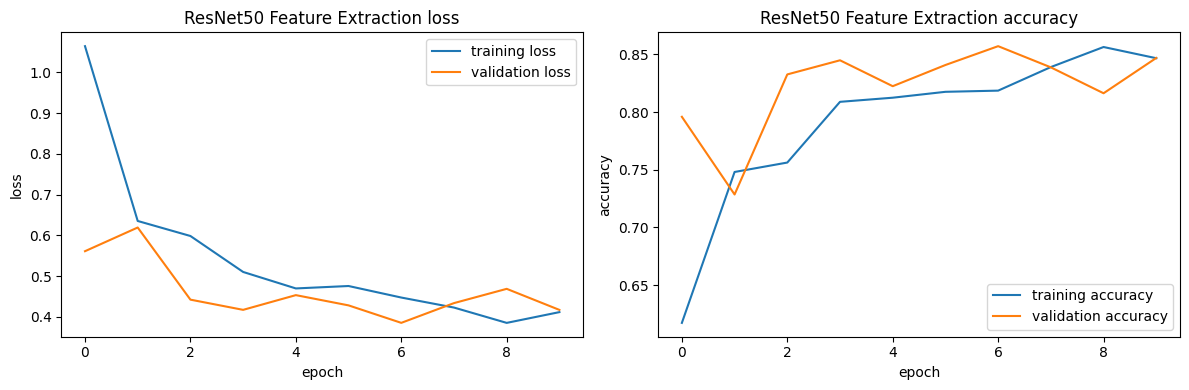

In [106]:
plot_history(resnet_history, "ResNet50 Feature Extraction")

During feature extraction, the ResNet50 convolutional base was frozen. This means the pre-trained ImageNet weights were kept unchanged, and only the newly added classification layers were trained. This strategy is useful for smaller datasets because it reduces training time and lowers the risk of overfitting.


**Fine-Tuning**

In [107]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


In [108]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [109]:
epochs_finetune = 10

start_time = time.time()

resnet_finetune_history = resnet_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=epochs_finetune
)

resnet_finetune_time = time.time() - start_time

print("ResNet50 fine-tuning time:", resnet_finetune_time, "seconds")

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 51s 502ms/step - accuracy: 0.7771 - loss: 0.5245 - val_accuracy: 0.8388 - val_loss: 0.4166
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 307ms/step - accuracy: 0.8671 - loss: 0.3634 - val_accuracy: 0.8816 - val_loss: 0.3475
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 301ms/step - accuracy: 0.8940 - loss: 0.3051 - val_accuracy: 0.8776 - val_loss: 0.3078
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 300ms/step - accuracy: 0.9242 - loss: 0.2529 - val_accuracy: 0.8837 - val_loss: 0.3035
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 304ms/step - accuracy: 0.9170 - loss: 0.2346 - val_accuracy: 0.8959 - val_loss: 0.2954
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 309ms/step - accuracy: 0.9211 - loss: 0.2283 - val_accuracy: 0.8980 - val_loss: 0.2936
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 305ms/step - accuracy: 0.9262 - loss: 0.2049 - val_accuracy: 0.9041 - val_loss: 0.2617
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 303ms/step - accuracy: 0.9468 - loss: 0.1737 - val_accu

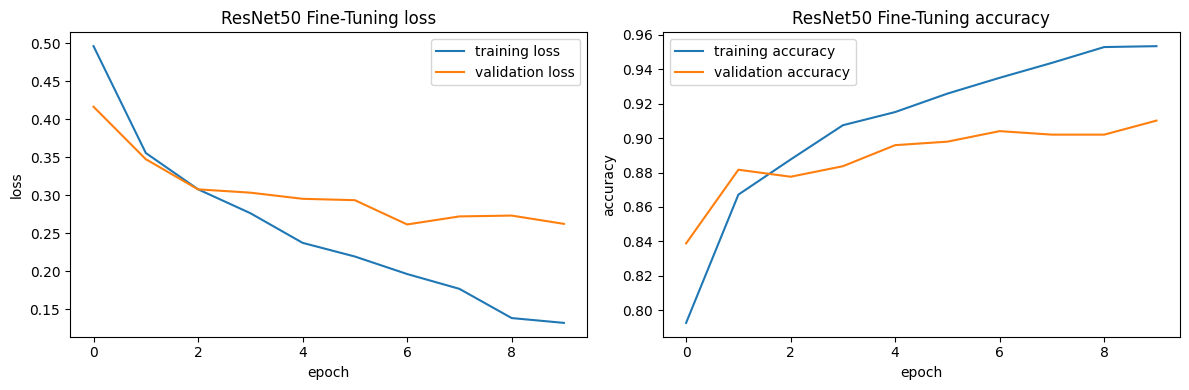

In [110]:
plot_history(resnet_finetune_history, "ResNet50 Fine-Tuning")

For fine-tuning, the last 30 layers of ResNet50 were unfrozen while earlier layers remained frozen. A very low learning rate was used to avoid large updates to the pre-trained weights. This allows the model to adapt higher-level features to the MRI dataset while reducing the risk of catastrophic forgetting.

### Model Evaluation and Prediction


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 368ms/step
Fine-Tuned ResNet50
loss: 0.2992825508117676
accuracy: 0.9049919247627258
precision: 0.9057899593087105
recall: 0.9049919484702094
f1-score: 0.9050413429662719
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.87      0.89       181
meningioma_tumor       0.85      0.87      0.86       183
          normal       0.96      0.92      0.94        88
 pituitary_tumor       0.93      0.96      0.95       169

        accuracy                           0.90       621
       macro avg       0.91      0.91      0.91       621
    weighted avg       0.91      0.90      0.91       621



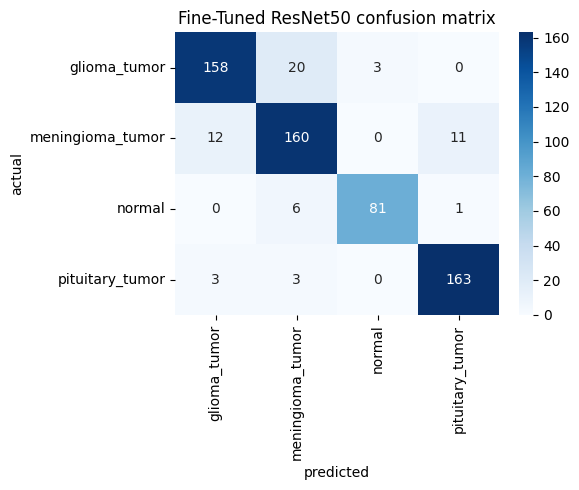

{'model': 'Fine-Tuned ResNet50',
 'loss': 0.2992825508117676,
 'accuracy': 0.9049919247627258,
 'precision': 0.9057899593087105,
 'recall': 0.9049919484702094,
 'f1_score': 0.9050413429662719}

In [111]:
resnet_result = evaluate_model(
    resnet_model,
    transfer_test_ds,
    "Fine-Tuned ResNet50"
)

resnet_result

The Fine-Tuned ResNet50 achieved 90.50% accuracy and 90.50% F1-score, making it the best-performing model. It correctly classified most images across all four classes, especially pituitary tumor and normal images. Some confusion still occurred between glioma and meningioma, but overall transfer learning performed better than the CNN models trained from scratch.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


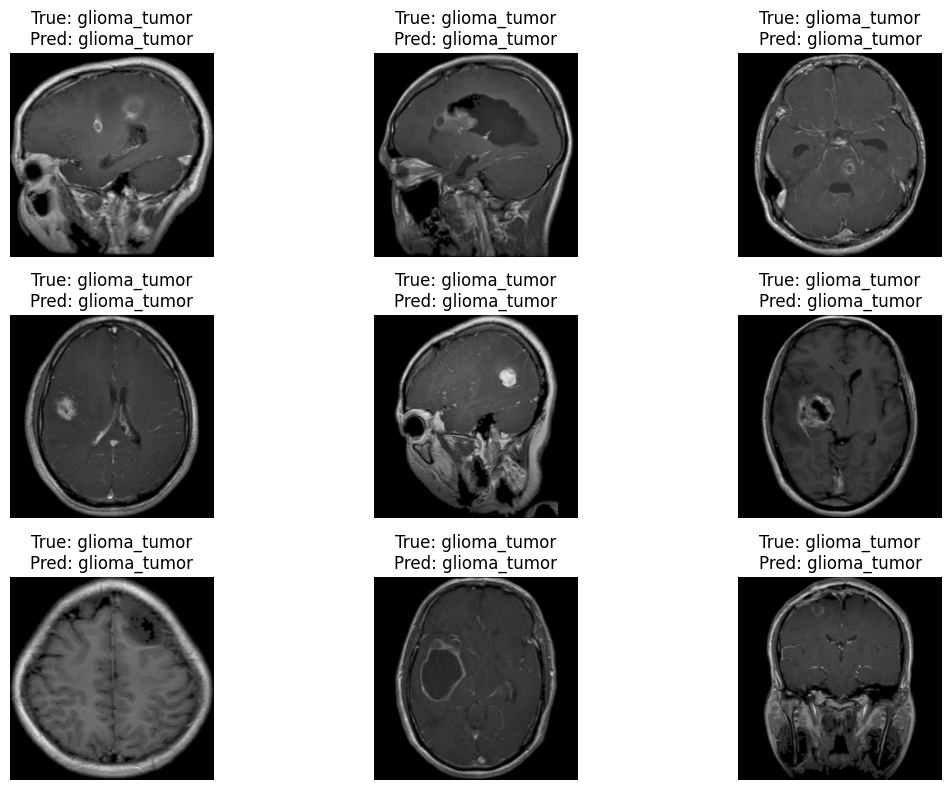

In [112]:
for images, labels in transfer_test_ds.take(1):
    predictions = resnet_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            "True: " + class_names[int(labels[i])] +
            "\nPred: " + class_names[int(predicted_labels[i])]
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

**Compare Transfer Learning With Part A Models**

In [113]:
def get_final_train_val(history):
    return {
        "train_accuracy": history.history["accuracy"][-1],
        "val_accuracy": history.history["val_accuracy"][-1],
        "train_loss": history.history["loss"][-1],
        "val_loss": history.history["val_loss"][-1]
    }

In [115]:
baseline_train_val = get_final_train_val(baseline_history)
deeper_adam_train_val = get_final_train_val(deeper_adam_history)
deeper_sgd_train_val = get_final_train_val(deeper_sgd_history)
ablation_train_val = get_final_train_val(ablation_history)
resnet_train_val = get_final_train_val(resnet_finetune_history)

final_comparison = pd.DataFrame([
    {
        "model": "baseline cnn",
        "train_accuracy": baseline_train_val["train_accuracy"],
        "val_accuracy": baseline_train_val["val_accuracy"],
        "test_accuracy": baseline_result["accuracy"],
        "test_f1_score": baseline_result["f1_score"],
        "test_loss": baseline_result["loss"],
        "training_time": baseline_time
    },
    {
        "model": "deeper cnn adam",
        "train_accuracy": deeper_adam_train_val["train_accuracy"],
        "val_accuracy": deeper_adam_train_val["val_accuracy"],
        "test_accuracy": deeper_adam_result["accuracy"],
        "test_f1_score": deeper_adam_result["f1_score"],
        "test_loss": deeper_adam_result["loss"],
        "training_time": deeper_adam_time
    },
    {
        "model": "deeper cnn sgd",
        "train_accuracy": deeper_sgd_train_val["train_accuracy"],
        "val_accuracy": deeper_sgd_train_val["val_accuracy"],
        "test_accuracy": deeper_sgd_result["accuracy"],
        "test_f1_score": deeper_sgd_result["f1_score"],
        "test_loss": deeper_sgd_result["loss"],
        "training_time": deeper_sgd_time
    },
    {
        "model": "ablation without dropout",
        "train_accuracy": ablation_train_val["train_accuracy"],
        "val_accuracy": ablation_train_val["val_accuracy"],
        "test_accuracy": ablation_result["accuracy"],
        "test_f1_score": ablation_result["f1_score"],
        "test_loss": ablation_result["loss"],
        "training_time": ablation_time
    },
    {
        "model": "fine tuned resnet50",
        "train_accuracy": resnet_train_val["train_accuracy"],
        "val_accuracy": resnet_train_val["val_accuracy"],
        "test_accuracy": resnet_result["accuracy"],
        "test_f1_score": resnet_result["f1_score"],
        "test_loss": resnet_result["loss"],
        "training_time": resnet_feature_time + resnet_finetune_time
    }
])

display(final_comparison)

,model,train_accuracy,val_accuracy,test_accuracy,test_f1_score,test_loss,training_time
0,baseline cnn,0.912110,0.889796,0.890499,0.891011,0.404713,250.403968
1,deeper cnn adam,0.900869,0.820408,0.795491,0.791200,0.615373,331.483027
2,deeper cnn sgd,0.746040,0.726531,0.698873,0.693044,0.803924,347.134871
3,ablation without dropout,0.885539,0.857143,0.837359,0.834158,0.560282,349.869106
4,fine tuned resnet50,0.953500,0.910204,0.904992,0.905041,0.299283,415.302457


In [116]:
display_comparison = final_comparison.copy()

percent_cols = [
    "train_accuracy",
    "val_accuracy",
    "test_accuracy",
    "test_f1_score"
]

for col in percent_cols:
    display_comparison[col] = (display_comparison[col] * 100).round(2).astype(str) + "%"

display_comparison["test_loss"] = display_comparison["test_loss"].round(4)
display_comparison["training_time"] = display_comparison["training_time"].round(2)

display(display_comparison)

,model,train_accuracy,val_accuracy,test_accuracy,test_f1_score,test_loss,training_time
0,baseline cnn,91.21%,88.98%,89.05%,89.1%,0.4047,250.40
1,deeper cnn adam,90.09%,82.04%,79.55%,79.12%,0.6154,331.48
2,deeper cnn sgd,74.6%,72.65%,69.89%,69.3%,0.8039,347.13
3,ablation without dropout,88.55%,85.71%,83.74%,83.42%,0.5603,349.87
4,fine tuned resnet50,95.35%,91.02%,90.5%,90.5%,0.2993,415.30


The Fine-Tuned ResNet50 model performed best, achieving 90.50% test accuracy and 90.50% F1-score, with the lowest test loss of 0.2993.

It improved accuracy by about 1.45 percentage points compared to the baseline CNN, which achieved 89.05% accuracy. This shows that transfer learning was slightly more effective than training CNN models from scratch.

The deeper CNN with regularization and the no-dropout model performed lower than the baseline, while the deeper CNN with SGD performed worst. Overall, Fine-Tuned ResNet50 gave the strongest and most reliable results.

**Discuss whether transfer learning outperforms training from scratch.**

Transfer learning slightly outperformed training from scratch for this dataset. The Fine-Tuned ResNet50 achieved 90.50% test accuracy and 90.50% F1-score, while the best model trained from scratch, the baseline CNN, achieved 89.05% accuracy and 89.10% F1-score. This shows that the pretrained ResNet50 features helped improve performance, although the improvement was small. Overall, transfer learning was the best approach for this dataset.

**Conclusion**

This project compared multiple deep learning models for brain tumor MRI classification across four classes: glioma tumor, meningioma tumor, pituitary tumor, and normal. The dataset was cleaned by removing corrupted images, and preprocessing steps such as resizing, normalization, and data augmentation were applied.

The baseline CNN achieved 89.05% accuracy, while the deeper CNN with regularization achieved 79.55% accuracy. This showed that adding more layers and regularization did not automatically improve performance. Adam performed better than SGD, and the ablation model without dropout improved the deeper CNN result to 83.74%.

The best model was the Fine-Tuned ResNet50, which achieved 90.50% accuracy and 90.50% F1-score. Overall, transfer learning performed slightly better than the CNN models trained from scratch and was the most effective approach for this task.

In [117]:
total_training_time_seconds = (
    baseline_time +
    deeper_adam_time +
    deeper_sgd_time +
    ablation_time +
    resnet_feature_time +
    resnet_finetune_time
)

gpu_hours = total_training_time_seconds / 3600

gpu_power_kw = 0.07
carbon_intensity = 0.475

energy_kwh = gpu_hours * gpu_power_kw
carbon_kg = energy_kwh * carbon_intensity

print("total training time seconds:", total_training_time_seconds)
print("gpu hours:", gpu_hours)
print("estimated energy kwh:", energy_kwh)
print("estimated carbon footprint kg co2:", carbon_kg)

total training time seconds: 1694.1934287548065
gpu hours: 0.47060928576522404
estimated energy kwh: 0.032942650003565686
estimated carbon footprint kg co2: 0.0156477587516937
